In [1]:
import kagglehub
path = kagglehub.dataset_download("abdallahwagih/spam-emails")

100%|██████████| 207k/207k [00:00<00:00, 53.2MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# List files in the downloaded directory
print(f"Files in dataset directory: {os.listdir(path)}")

Files in dataset directory: ['spam.csv']


From the listed files, 'spam_ham_dataset.csv' appears to be the main data file. Let's load it into a pandas DataFrame and inspect its first few rows.

In [6]:
file_path = os.path.join(path, 'spam.csv')
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None

In [9]:
# Check the distribution of the target variable (label)
display(df['Category'].value_counts())

,count
Category,
ham,4825
spam,747


### Data Preprocessing for Deep Learning

To prepare the text data for a deep learning model, we need to perform several preprocessing steps:

1.  **Label Encoding**: Convert 'ham' and 'spam' categories into numerical labels (0 and 1).
2.  **Text Cleaning**: Convert text to lowercase.
3.  **Text Tokenization**: Convert text into sequences of integers (representing words).
4.  **Padding Sequences**: Ensure all sequences have the same length for input into the neural network.

In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Label Encoding
le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

# Prepare features (X) and labels (y)
X = df['Message']
y = df['Category_encoded']

# 2. Text Tokenization and Preprocessing
# Define vocabulary size (max number of words to keep)
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')
tokenizer.fit_on_texts(X)

X_sequences = tokenizer.texts_to_sequences(X)

# Determine max sequence length for padding
MAX_SEQUENCE_LENGTH = max([len(x) for x in X_sequences])
print(f"Maximum sequence length: {MAX_SEQUENCE_LENGTH}")

# 3. Padding Sequences
X_padded = pad_sequences(X_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

print(f"Shape of padded sequences: {X_padded.shape}")
print(f"Shape of labels: {y.shape}")

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Maximum sequence length: 189
Shape of padded sequences: (5572, 189)
Shape of labels: (5572,)
X_train shape: (4457, 189)
X_test shape: (1115, 189)
y_train shape: (4457,)
y_test shape: (1115,)


### Building and Training the Deep Learning Model

Now that the data is preprocessed, we can define and train a deep learning model. A common architecture for text classification is a Recurrent Neural Network (RNN), such as an LSTM, or a simple Feedforward Neural Network with an Embedding layer. Given the relatively small dataset size, we'll start with a straightforward architecture.

We will use:
*   An **Embedding layer** to convert word indices into dense vectors.
*   A **Flatten layer** to prepare the output for dense layers.
*   **Dense layers** for classification.
*   **Dropout** for regularization to prevent overfitting.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout, Input

# Define model parameters
EMBEDDING_DIM = 100 # Dimension of the dense embedding

# Build the model with an explicit Input layer
model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)), # Explicitly define input shape
    Embedding(VOCAB_SIZE, EMBEDDING_DIM), # input_length is no longer needed
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
BATCH_SIZE = 32
EPOCHS = 10

history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 189, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18900)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,209,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,209,729 (8.43 MB)

 Trainable params: 2,209,729 (8.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9135 - loss: 0.2340 - val_accuracy: 0.9664 - val_loss: 0.1249
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9818 - loss: 0.0820 - val_accuracy: 0.9865 - val_loss: 0.0657
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9920 - loss: 0.0454 - val_accuracy: 0.9888 - val_loss: 0.0554
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9973 - loss: 0.0298 - val_accuracy: 0.9910 - val_loss: 0.0526
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9983 - loss: 0.0223 - val_accuracy: 0.9910 - val_loss: 0.0615
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9993 - loss: 0.0215 - val_accuracy: 0.9910 - val_loss: 0.0544
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9995 - loss: 0.0190 - val_accuracy: 0.9910 - val_loss: 0.0643
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9998 - loss: 0.0177 - val_accu

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout, Input

# Define model parameters
EMBEDDING_DIM = 100 # Dimension of the dense embedding

# Build the model with an explicit Input layer
model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)), # Explicitly define input shape
    Embedding(VOCAB_SIZE, EMBEDDING_DIM), # input_length is no longer needed
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
BATCH_SIZE = 32
EPOCHS = 10

history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 189, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18900)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,209,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,209,729 (8.43 MB)

 Trainable params: 2,209,729 (8.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9112 - loss: 0.2319 - val_accuracy: 0.9709 - val_loss: 0.1210
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9828 - loss: 0.0897 - val_accuracy: 0.9821 - val_loss: 0.0803
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9923 - loss: 0.0601 - val_accuracy: 0.9888 - val_loss: 0.0645
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9965 - loss: 0.0484 - val_accuracy: 0.9910 - val_loss: 0.0693
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9970 - loss: 0.0148 - val_accuracy: 0.9865 - val_loss: 0.0758
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9888 - val_loss: 0.0707
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9888 - val_loss: 0.0748
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9998 - loss: 6.3734e-04 - val_

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



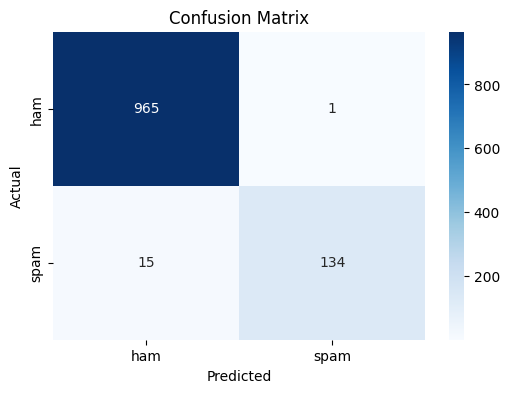

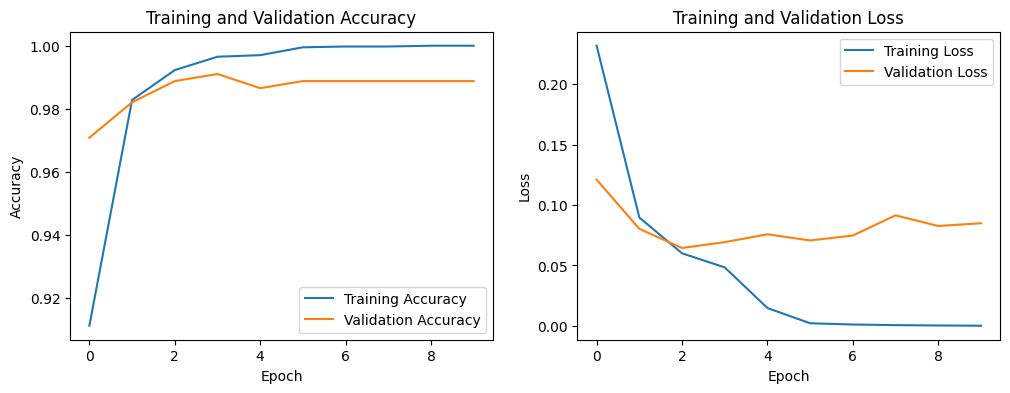

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Model Evaluation and Further Steps

The model has been trained and evaluated. The next steps involve analyzing its performance more deeply, especially considering the imbalanced dataset. We should look at metrics like precision, recall, and F1-score, and potentially use techniques like class weighting or over/under-sampling to address the imbalance.

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



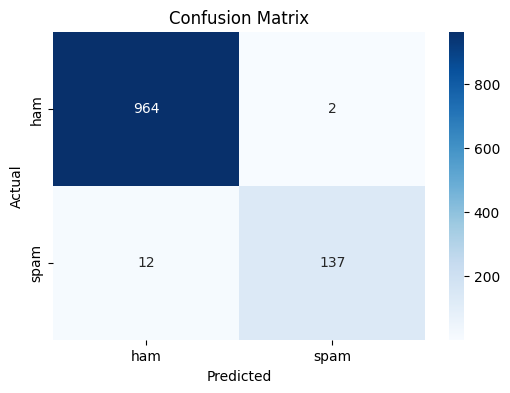

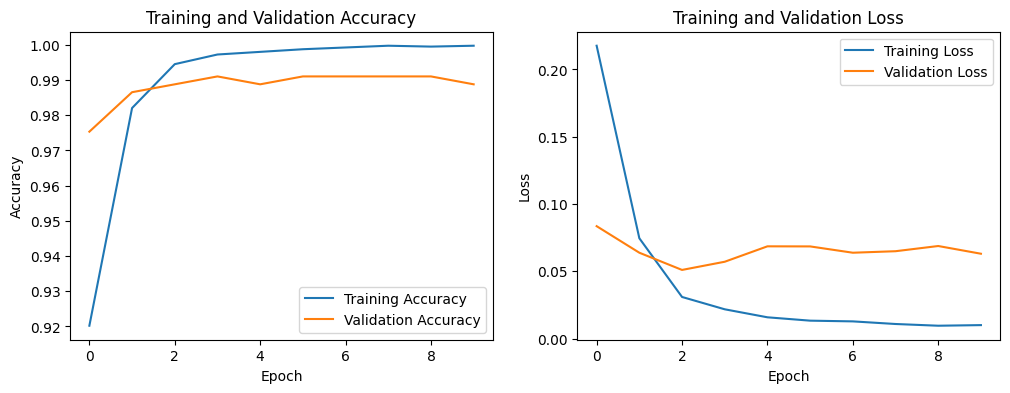

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Saving Model Components for Streamlit App

To use the trained deep learning model and its preprocessing components (Tokenizer and LabelEncoder) within a Streamlit application, we need to save them to disk. The Keras model can be saved directly, while the `Tokenizer` and `LabelEncoder` can be saved using Python's `pickle` module.

In [20]:
import pickle
import os

# Create a directory to save the model and related components
model_dir = 'streamlit_model_components'
os.makedirs(model_dir, exist_ok=True)

# Save the Keras model
model_path = os.path.join(model_dir, 'spam_classifier_model.keras')
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save the Tokenizer
tokenizer_path = os.path.join(model_dir, 'tokenizer.pkl')
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved to: {tokenizer_path}")

# Save the LabelEncoder
label_encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
with open(label_encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"LabelEncoder saved to: {label_encoder_path}")

# Also save MAX_SEQUENCE_LENGTH and VOCAB_SIZE for consistent use in the app
with open(os.path.join(model_dir, 'model_params.pkl'), 'wb') as f:
    pickle.dump({'MAX_SEQUENCE_LENGTH': MAX_SEQUENCE_LENGTH, 'VOCAB_SIZE': VOCAB_SIZE}, f)
print("Model parameters saved.")

Model saved to: streamlit_model_components/spam_classifier_model.keras
Tokenizer saved to: streamlit_model_components/tokenizer.pkl
LabelEncoder saved to: streamlit_model_components/label_encoder.pkl
Model parameters saved.


### Create Streamlit Application (app.py)

Now, let's create the `app.py` file which will be our Streamlit application. This script will:
1.  Install necessary libraries if not already installed (`pip install streamlit tensorflow scikit-learn`).
2.  Load the saved model, tokenizer, and label encoder.
3.  Provide a text area for users to enter a message.
4.  On button click, preprocess the message, predict its category (spam/ham), and display the result.

In [28]:
%%writefile streamlit_app.py

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import os
import time # Import time for spinner

# Set page config for a wider layout
st.set_page_config(page_title="Spam/Ham Message Classifier", layout="centered")

# Load model components
@st.cache_resource
def load_model_components():
    model_dir = 'streamlit_model_components'

    model = tf.keras.models.load_model(os.path.join(model_dir, 'spam_classifier_model.keras'))

    with open(os.path.join(model_dir, 'tokenizer.pkl'), 'rb') as f:
        tokenizer = pickle.load(f)

    with open(os.path.join(model_dir, 'label_encoder.pkl'), 'rb') as f:
        le = pickle.load(f)

    with open(os.path.join(model_dir, 'model_params.pkl'), 'rb') as f:
        params = pickle.load(f)

    return model, tokenizer, le, params['MAX_SEQUENCE_LENGTH'], params['VOCAB_SIZE']

model, tokenizer, le, MAX_SEQUENCE_LENGTH, VOCAB_SIZE = load_model_components()

# --- Sidebar --- #
st.sidebar.title("About This App")
st.sidebar.info(
    "This application uses a Deep Learning model to classify text messages "
    "as either 'Spam' or 'Ham' (not spam)."
)
st.sidebar.header("Model Details")
st.sidebar.markdown(f"- **Vocabulary Size:** {VOCAB_SIZE}")
st.sidebar.markdown(f"- **Max Sequence Length:** {MAX_SEQUENCE_LENGTH}")
st.sidebar.markdown("- **Model Architecture:** Embedding -> Flatten -> Dense -> Dropout -> Dense")
st.sidebar.markdown("- **Developed by:** Colab AI Agent")

# --- Main Content --- #

st.title("✉️ Spam/Ham Message Classifier")
st.markdown("Enter a message below and click 'Classify' to determine if it's spam or not.")

# Text Area for user input
user_input = st.text_area("Enter your message here:", "", height=150, placeholder="Type your message...")

# Classify button
if st.button("Classify Message", type="primary"):
    if user_input:
        with st.spinner('Classifying...'):
            time.sleep(1) # Simulate processing time
            # Preprocess the input message
            input_sequence = tokenizer.texts_to_sequences([user_input])
            padded_input = pad_sequences(input_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

            # Make prediction
            prediction = model.predict(padded_input, verbose=0)[0][0] # verbose=0 to suppress output

            # Get predicted label
            predicted_class_index = (prediction > 0.5).astype(int)
            predicted_label = le.inverse_transform([predicted_class_index])[0]

        st.subheader("Classification Result:")
        if predicted_label == 'spam':
            st.error(f"### 🚨 This message is likely **SPAM**!"
                     f"\n\n*Confidence (Spam probability):* `{prediction:.4f}`")
        else:
            st.success(f"### ✅ This message is likely **HAM**."
                       f"\n\n*Confidence (Ham probability):* `{1 - prediction:.4f}`")

        st.write("--- ")
        st.markdown("**Original Message:**")
        st.code(user_input, language='text')

    else:
        st.warning("Please enter a message to classify.")

st.markdown("Built with Streamlit and TensorFlow.")


Overwriting streamlit_app.py


### Run the Streamlit Application

To run the Streamlit application, you will need to open a new terminal in Colab and execute the following commands. If you are running this notebook in a local environment, open your terminal/command prompt, navigate to the directory where `streamlit_app.py` is saved, and run the command.

First, install Streamlit if you haven't already:
```bash
pip install streamlit
```

Then, run the application:
```bash
streamlit run streamlit_app.py --server.port 8000
```

After running the command, Streamlit will provide a local URL (e.g., `http://localhost:8000`) and a network URL (e.g., `http://<external-IP>:8000`). If you are in Colab, it will also provide a public URL via ngrok. Click on the public URL to access your application in a new browser tab. You might need to install `ngrok` first.

Once the app is running, you can enter text messages into the provided text area and click 'Classify' to see the model's prediction.

In [16]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Category          5572 non-null   object
 1   Message           5572 non-null   object
 2   Category_encoded  5572 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 130.7+ KB


None

In [19]:
# Check the distribution of the target variable (label)
display(df['Category'].value_counts())

,count
Category,
ham,4825
spam,747


In [22]:
!pip install --ignore-installed blinker
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.9 MB/s eta 0:00:00


In [23]:
!pip install streamlit pyngrok

In [24]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [29]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [30]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run streamlit_app.py &




2026-08-11 13:11:14.575 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.13.178:8501

2026-08-11 13:11:22.858464: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Stopping...
